# VirtualMars — the simulated robot, without ROS

`VirtualMars` (`ros2_ws/src/mars_bot/mars_sim_driver/mars_sim_driver/core.py`) is the whole simulated world in one Python object: headless MuJoCo physics of the apartment + the real `mars.urdf`, with the robot's cameras rendered offscreen. No ROS anywhere — this notebook drives it directly, the same object the `mars_sim_driver` ROS node wraps in `./innate-sim up`.

**Setup** (once):

```bash
cd sim && uv sync --group notebook
```

then open this notebook on the `sim/.venv` kernel. The apartment assets in `sim/assets` are fetched by `./innate-sim up` (or set `VIRTUAL_MARS_ASSETS` to a copy; to regenerate from scratch see `sim/sandbox/README.md`).

On a headless Linux box set `MUJOCO_GL=egl` (or `osmesa`) before the first import; on a Mac the default works.

In [1]:
import _driver_pkg  # noqa: F401 -- sys.path bootstrap so mars_sim_driver imports (kernel cwd must be sim/sandbox)
import matplotlib.pyplot as plt
import numpy as np
from mars_sim_driver.core import VirtualMars

sim = VirtualMars()
sim.step(1.0)  # let the robot settle from its spawn drop
print("pose (x, y, yaw):", sim.pose())

pose (x, y, yaw): (-4.33999999926847, -0.1700000000103217, -1.567305667596041)


## RGB observations

Two cameras, matching the real robot: `main` (head) and `wrist` (arm). These are the pixels the brain agent sees — ACES-tonemapped to match the Three.js viewer's look.

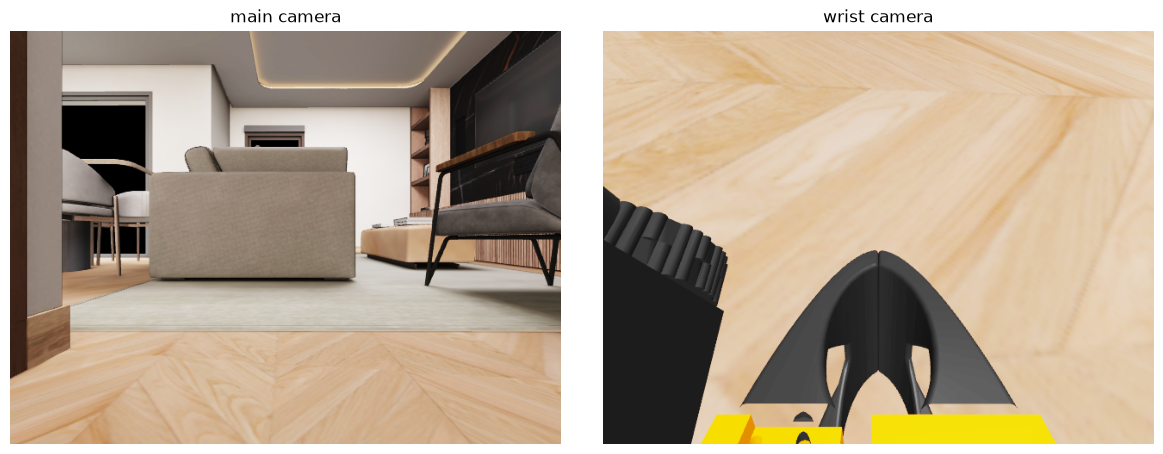

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, cam in zip(axes, ("main", "wrist"), strict=True):
    ax.imshow(sim.render_rgb(cam))
    ax.set_title(f"{cam} camera")
    ax.axis("off")
plt.tight_layout()

## Depth

Raw metric depth from the main camera. The robot's own geometry is excluded from the depth render — the real stereo pipeline can't resolve the arm that close to the lens either. (The ROS driver additionally clamps to the real device's [0.25, 2.0] m range.)

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

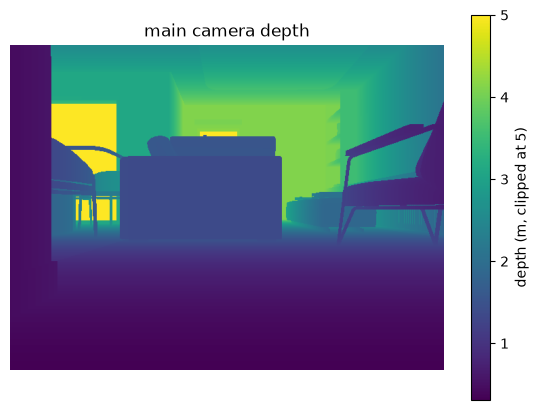

In [3]:
depth = sim.render_depth("main")
plt.figure(figsize=(7, 5))
im = plt.imshow(np.clip(depth, 0, 5), cmap="viridis")
plt.colorbar(im, label="depth (m, clipped at 5)")
plt.title("main camera depth")
plt.axis("off")

## Occupancy grid

`occupancy_grid()` rasterizes the collision world into a nav map by casting a downward ray per 5 cm cell (the robot is teleported out of bounds for the scan). Values: `-1` unknown, `0` free, `100` occupied. This is the same map `sim/tools/export_nav_map.py` saves for the real Nav2 map server. One-time cost ~1 s (~40k rays).

Text(0.5, 1.0, 'occupancy grid (white=free, black=occupied, gray=unknown)')

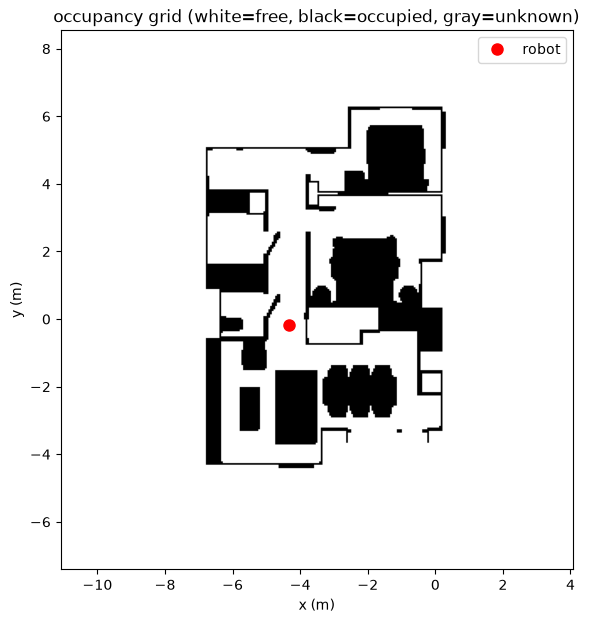

In [5]:
RES = 0.05
grid, ox, oy = sim.occupancy_grid(RES)
extent = (ox, ox + grid.shape[1] * RES, oy, oy + grid.shape[0] * RES)


def show_map(ax):
    shade = np.select([grid == -1, grid == 0, grid == 100], [0.6, 1.0, 0.0])
    ax.imshow(shade, cmap="gray", vmin=0, vmax=1, origin="lower", extent=extent)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")


fig, ax = plt.subplots(figsize=(7, 7))
show_map(ax)
x, y, _ = sim.pose()
ax.plot(x, y, "ro", markersize=8, label="robot")
ax.legend()
ax.set_title("occupancy grid (white=free, black=occupied, gray=unknown)")

## Lidar

A 360° planar scan from the lidar mount, raycast against the true visual surfaces (like a real lidar — not the ~1 cm-inflated collision hulls). Distances in meters, CCW from the robot's +x.

Text(0.5, 1.0, 'lidar scan over the occupancy grid')

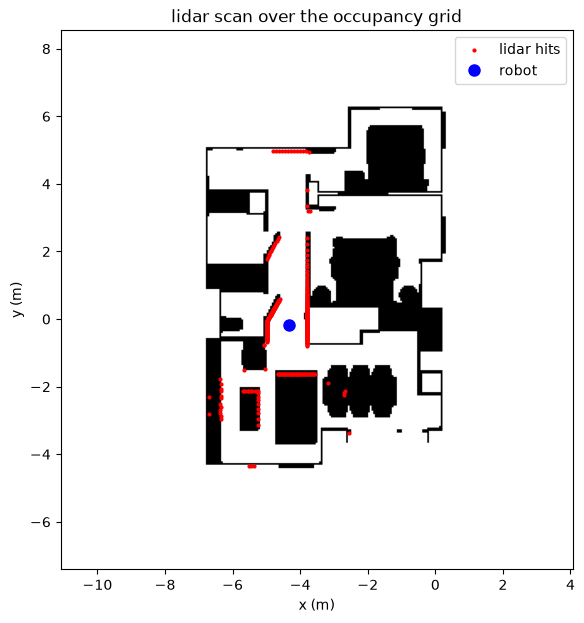

In [6]:
N_RAYS, MAX_RANGE = 360, 12.0
scan = sim.lidar_scan(N_RAYS, MAX_RANGE)
x, y, yaw = sim.pose()
angles = yaw + np.arange(N_RAYS) * (2 * np.pi / N_RAYS)
hit = scan < MAX_RANGE

fig, ax = plt.subplots(figsize=(7, 7))
show_map(ax)
ax.scatter(x + scan[hit] * np.cos(angles[hit]), y + scan[hit] * np.sin(angles[hit]), s=4, c="red", label="lidar hits")
ax.plot(x, y, "bo", markersize=8, label="robot")
ax.legend()
ax.set_title("lidar scan over the occupancy grid")

## Driving

`set_cmd_vel(vx, wz)` is the base command, with the real driver's 0.5 s stale-command watchdog — re-issue it at least every half second (exactly like publishing `/cmd_vel`). Collisions are simulated: drive into the couch and the couch wins.

In [ ]:
sim.reset()
sim.step(1.0)

traj = [sim.pose()[:2]]
for _ in range(60):  # 6 s: forward while turning -> an arc
    sim.set_cmd_vel(0.3, 0.4)  # refresh before the watchdog trips
    sim.step(0.1)
    traj.append(sim.pose()[:2])
sim.set_cmd_vel(0.0, 0.0)
traj = np.array(traj)

fig, ax = plt.subplots(figsize=(7, 7))
show_map(ax)
ax.plot(traj[:, 0], traj[:, 1], "r-", linewidth=2, label="trajectory")
ax.plot(*traj[0], "go", markersize=8, label="start")
ax.plot(*traj[-1], "ro", markersize=8, label="end")
ax.legend()
ax.set_title("cmd_vel arc through the apartment")

## Arm

The arm and head are PD-servoed to per-joint targets (`joint1..joint6`, `joint_head`), starting from the same home pose the webapp uses. Watch the wrist camera move.

In [ ]:
before = sim.render_rgb("wrist")

sim.set_joint_target("joint2", -0.6)  # reach forward
sim.set_joint_target("joint3", 0.8)
sim.set_joint_target("joint_head", np.radians(-20))  # tilt head down
sim.step(2.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (img, title) in zip(axes, ((before, "wrist before"), (sim.render_rgb("wrist"), "wrist after")), strict=True):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()

{k: round(v, 3) for k, v in sim.joint_positions().items()}

## Where to go from here

- **Parallel experiments**: each `VirtualMars()` is independent — instantiate N in one
  process (or N processes) for batch rollouts. Rendering is lazy; pure physics is cheap.
- **The full robot stack** against this same world: `./innate sim up` — the
  `mars_sim_driver` ROS node (`node.py`) wraps this object and impersonates the hardware drivers, so Nav2/brain/webapp run unchanged.
- **Interactive MuJoCo viewers**: `uv run sandbox/drive_mars.py` (WASD + browser control
  panel), `uv run sandbox/stress_test_apartment.py` after any collision-mesh change.
- **Model construction** (world MJCF, URDF attach, gains): `mars_sim_driver/world.py` —
  the layer a GPU/batched backend would reuse.